Title chat: Mixed effect model for image quality to model accuracy.
I want you to read the chat transcript below and then understand and memorize what the goal is, and then start building this notebook here /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/ARC_ATLAS_Test_v3_All_Stats.ipynb:
"took a look through the the-brAIn‑lab/Lesion_Mapping repository you’re using for the paper. In the ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval directory there are separate summary files for the synthetic high‑resolution, low‑resolution and various degraded test sets (e.g., test_hires_metrics_summary_…, test_lores_metrics_summary_…, test_crude_metrics_summary_… etc.). These summaries show that Dice and related metrics degrade when the images are downsampled: for example, in the high‑res test set the micro Dice (soft) is about 0.746, whereas in the low‑res test set it drops to ~0.687. That difference aligns with what you see in Fig. 6 and gives some reassurance that your synthetic degradations capture the performance drop you observe in real low‑resolution data.

Thoughts on the mixed‑effects/GAM approach

The plan sketched in the earlier chat looks sound. Using a mixed‑effects model (logit‑transformed Dice as the outcome, with standardized FWHM, high‑frequency energy (HFE) and Laplacian variance as predictors) will let you quantify within‑subject relationships between quality and performance. Random intercepts account for subject‑specific baseline performance, and you can add random slopes if you suspect that, for example, some brains are more sensitive to blur than others. Adding a binary indicator for “rigid jitter” (or a continuous misalignment metric when it becomes available) will help you separate out misalignment‑induced failures from noise/blur‑induced degradations. This approach is more principled than a single straight‑line fit because it handles the bounded nature of Dice, accommodates non‑linearity (via GAM or splines), and explicitly models subject‑level variability.

Handling the natural low‑resolution test set

Your confusion about the low‑res cohort stems from the fact that it isn’t paired with corresponding high‑res images, so you can’t include it as a random effect in the same way as the synthetic degradations. Treating it as an external hold‑out cohort, as suggested, is a way to test generalisation rather than improve the model fit:

Train the mixed‑effects/GAM model on the synthetic degradations only. Use the paired synthetic data to learn how Dice depends on FWHM, HFE, LapVar and the misalignment indicator.

Predict performance for each subject in the natural low‑res cohort using their measured quality metrics. Because the natural cohort is unpaired, you’d drop the random intercept (or set it to zero) when predicting; the model’s fixed effects give you expected Dice given HFE/FWHM/LapVar.

Compare the predicted Dice to the actual Dice for the natural cohort. A calibration plot (predicted vs. observed) and residual analysis will show whether the quality metrics learned from the synthetic degradations adequately explain performance on real low‑res images. If the natural cohort falls systematically below the predicted line, it suggests that there is an additional penalty (e.g., due to unmodelled scanner differences or pathology) that isn’t captured by your quality metrics.

This “train on synthetic, test on natural” strategy serves as an external validity check. It tells readers that your synthetic degradations are not just over‑fitting the training cohort but actually capture the degradation mechanisms present in real clinical data. Alternatively, you could include the natural cohort in the model with a cohort indicator (natural vs. synthetic) without pairing; this would estimate an overall offset for natural images but might complicate interpretation. Holding it out and predicting keeps the story cleaner and lets you report statements like “for natural low‑resolution scans, the model trained on synthetic degradations overestimates Dice by X points, indicating an additional penalty not explained by blur/noise metrics.”

In summary, the suggested mixed‑effects/GAM framework is a robust way to quantify how quality metrics relate to segmentation performance and to isolate misalignment effects. Holding out the natural low‑res cohort and predicting on it is not meant to improve model accuracy but to demonstrate that the relationship you learned from synthetic degradations generalises to real low‑res data; the magnitude and direction of prediction errors will quantify any residual performance gap.

Sources
good now can you go through ARC_ATLAS_Train_v3 and determine based on everything that has been run in all the notebooks, which all files I will need to make a perform this test. and a sort of outline on how I should compile a new notebook and what all steps i need to do

Here is a consolidated list of the key files in the ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval directory that you will need for the mixed‑effects/GAM analysis and an outline for compiling a new notebook:

Essential data files

The per‑case metrics and quality metrics you need are stored in the metrics‑with‑manifest CSVs for each test cohort. They all share a common structure: columns for segmentation performance (soft_dice, hard_dice_at_0.50, precision, recall, hd, hd95, assd), subject keys (key or mf_key), and image quality metrics (mf_fwhm_mm, mf_hi_freq_energy, mf_lap_var, mf_score) plus a binary misalignment indicator (mf_bin). The dataset_tag column specifies which degradation was applied. Example rows are shown in the cited files for the hires, crude, InPlane and natural low‑res cohorts.

You will need one CSV for each degradation type:

File	Purpose	Notes
test_hires_metrics_with_manifest_20251111_122946.csv	High‑resolution synthetic baseline	Contains per‑case metrics and quality metrics; dataset_tag = hires.
test_crude_metrics_with_manifest_20251111_155445.csv	Synthetic downsampling with crude blur/noise	Same columns; dataset_tag = crude.
test_InPlane_metrics_with_manifest_20251111_163449.csv	Synthetic downsampling simulating in‑plane resolution	Same structure; dataset_tag = InPlane.
test_reducedsnr_metrics_with_manifest_*.csv	Synthetic reduced‑SNR downsampling	(You haven’t opened this yet, but it follows the same format.)
test_lores_metrics_with_manifest_20251111_161029.csv	Natural low‑resolution cohort (external hold‑out)	Contains the same columns; dataset_tag = lores and serves as the unpaired validation set.

Each of these files lives under ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval. You can ignore test_metrics_with_manifest_FIXED_20251110_160551.csv, which is a joined per‑case CSV for the training run but not needed for the mixed‑effects analysis.

Outline for the new analysis notebook

Imports and data loading

Import pandas, numpy, statsmodels (or PyMC for Bayesian GAM), and plotting libraries.

Read the above CSV files into DataFrames. For convenience, add a cohort column (e.g., hires, crude, InPlane, reducedsnr, lores) based on dataset_tag.

Concatenate the DataFrames for all synthetic degradations (hires, crude, InPlane, reducedsnr) into one training DataFrame.

Pre‑processing

Select the outcome metric: soft Dice or hard Dice. Apply a logit transform to ensure the outcome spans the real line: logit_dice = log((dice + ε)/(1 – dice + ε)), where ε is a small constant to avoid 0/1.

Standardize the predictors (mf_fwhm_mm, mf_hi_freq_energy, mf_lap_var) within the training data: subtract mean and divide by standard deviation.

Create the misalignment indicator: for rigid‑jitter degradations, set misalign = 1; for blur/noise degradations, set misalign = 0. If mf_bin already encodes this, use it directly.

Use the subject identifier (mf_key or key) as the grouping variable for random effects.

Model fitting on synthetic data

Mixed‑effects model: Use statsmodels’ mixed‑linear model (MixedLM) with logit_dice as the outcome, predictors as fixed effects, and a random intercept for each subject. Optionally include a random slope for one quality metric if you suspect subject‑specific sensitivities.

GAM or spline terms: To capture non‑linearity, either fit a GAM using a library like pygam or include spline basis functions (e.g., splines=bs() from patsy) in the mixed model.

Report effect estimates: the change in Dice per 1‑SD decrease in HFE or increase in FWHM/LapVar, with 95% confidence intervals. Evaluate partial R² or variance explained. Quantify the additional penalty for misalignment by including the binary indicator and reporting its coefficient.

Prediction on natural low‑resolution cohort

Apply the same standardization parameters (mean/SD) from the training data to the lores cohort’s quality metrics.

Compute predicted Dice (on the logit scale) for the low‑res cases using the fixed‑effect portion of the fitted model (set random intercept to zero because subjects are unpaired). Back‑transform to the Dice scale with inverse logit.

Plot predicted vs. observed Dice for the low‑res cohort; examine residuals. A systematic negative bias would indicate an additional penalty not captured by the synthetic degradations.

Alternatively, include the low‑res data in a combined model with a cohort indicator (natural vs. synthetic) to estimate an overall offset, but keep this separate for a cleaner narrative.

Visualisations and reporting

Plot partial effect curves for each quality metric from the GAM/spline model with confidence bands. Overlay the misalignment points (rigid jitter) to show they fall below the expected curve.

Summarize results as: “Per 1 SD decrease in HFE, Dice changed by X (95% CI…) controlling for other metrics,” etc. Provide variance explained and misalignment penalty.

Discussion

Interpret how well quality metrics explain performance across synthetic degradations and whether the relationship generalizes to natural low‑res data.

Comment on any residual performance gap in the natural cohort and suggest further metrics or model refinements if needed.

This plan will let you assemble the necessary data from the ARC_ATLAS_Train_v3 outputs and perform the mixed‑effects/GAM analysis described in your previous chat."

## Notebook Build: Mixed-Effects Quality -> Accuracy Model

This notebook implements the requested workflow using the same run set as `ARC_ATLAS_Test_v3_All_Sets.ipynb`:
- load explicit manifests for `hires`, `crude_downsample`, `inplane_coarsening`, `thick_slice`, `reduced_snr`, and `rigid_jitter`,
- hold out **natural low-resolution** (`lower_resolution`) for external validation,
- fit a mixed-effects model on logit-transformed Dice,
- predict on the holdout using fixed effects,
- evaluate calibration and residual bias,
- optionally fit a spline-based GAM-like sensitivity model.


In [1]:
import importlib.util

REQUIRED = ["pandas", "numpy", "matplotlib", "statsmodels", "patsy", "scipy"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing) + "\n"
        "Install in this kernel with: %pip install " + " ".join(missing)
    )

print("All required packages are available.")


All required packages are available.


In [2]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [3]:
RUN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

# Mirrors ARC_ATLAS_Test_v3_All_Sets.ipynb run selections.
FILE_SPECS = [
    {"variant": "hires", "cohort": "hires", "role": "synthetic", "filename": "test_hires_metrics_with_manifest_20251111_130301.csv"},
    {"variant": "lower_resolution", "cohort": "lores", "role": "holdout", "filename": "test_lores_metrics_with_manifest_20251111_143340.csv"},
    {"variant": "crude_downsample", "cohort": "hires", "role": "synthetic", "filename": "test_crude_metrics_with_manifest_20251111_155445.csv"},
    {"variant": "thick_slice", "cohort": "hires", "role": "synthetic", "filename": "test_lores_metrics_with_manifest_20251111_161029.csv"},
    {"variant": "inplane_coarsening", "cohort": "hires", "role": "synthetic", "filename": "test_InPlane_metrics_with_manifest_20251111_163449.csv"},
    {"variant": "reduced_snr", "cohort": "hires", "role": "synthetic", "filename": "test_reducedsnr_metrics_with_manifest_20251111_181436.csv"},
    {"variant": "rigid_jitter", "cohort": "hires", "role": "synthetic", "filename": "test_slicejitter_metrics_with_manifest_20251111_172142.csv"},
]

missing = [spec["filename"] for spec in FILE_SPECS if not (RUN_DIR / spec["filename"]).exists()]
if missing:
    raise FileNotFoundError("Missing expected manifest files:\n- " + "\n- ".join(missing))

pd.DataFrame(FILE_SPECS)


,variant,cohort,role,filename
0,hires,hires,synthetic,test_hires_metrics_with_manifest_20251111_1303...
1,lower_resolution,lores,holdout,test_lores_metrics_with_manifest_20251111_1433...
2,crude_downsample,hires,synthetic,test_crude_metrics_with_manifest_20251111_1554...
3,thick_slice,hires,synthetic,test_lores_metrics_with_manifest_20251111_1610...
4,inplane_coarsening,hires,synthetic,test_InPlane_metrics_with_manifest_20251111_16...
5,reduced_snr,hires,synthetic,test_reducedsnr_metrics_with_manifest_20251111...
6,rigid_jitter,hires,synthetic,test_slicejitter_metrics_with_manifest_2025111...


In [4]:
REQUIRED_MANIFEST_COLS = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

dfs = {}
for spec in FILE_SPECS:
    path = RUN_DIR / spec["filename"]
    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_MANIFEST_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path.name} is missing required manifest columns: {missing_cols}. "
            "Use the *_metrics_with_manifest_*.csv file for this analysis."
        )

    if "dataset_tag" not in df.columns:
        df["dataset_tag"] = spec["cohort"]

    df["cohort"] = spec["cohort"]
    df["variant"] = spec["variant"]
    df["role"] = spec["role"]
    df["source_file"] = path.name

    dfs[spec["variant"]] = df

all_df = pd.concat(dfs.values(), ignore_index=True)

audit = (
    all_df.groupby(["variant", "cohort", "role"], dropna=False)
    .agg(
        n_rows=("key", "size"),
        n_subjects=("key", "nunique"),
        dice_mean=("soft_dice", "mean"),
        dice_std=("soft_dice", "std"),
    )
)
audit


,,,n_rows,n_subjects,dice_mean,dice_std
variant,cohort,role,,,,
crude_downsample,hires,synthetic,138,138,0.531373,0.273878
hires,hires,synthetic,138,138,0.588807,0.265854
inplane_coarsening,hires,synthetic,138,138,0.544371,0.269722
lower_resolution,lores,holdout,198,198,0.561594,0.280139
reduced_snr,hires,synthetic,138,138,0.587101,0.264024
rigid_jitter,hires,synthetic,138,138,0.460084,0.269906
thick_slice,hires,synthetic,138,138,0.508822,0.272144


In [5]:
# Pairing check across variants (by `key`)
variant_order = [spec["variant"] for spec in FILE_SPECS]
key_sets = {variant: set(dfs[variant]["key"].astype(str)) for variant in variant_order}

overlap = pd.DataFrame(index=variant_order, columns=variant_order, dtype=int)
for v1 in variant_order:
    for v2 in variant_order:
        overlap.loc[v1, v2] = len(key_sets[v1] & key_sets[v2])

overlap


,hires,lower_resolution,crude_downsample,thick_slice,inplane_coarsening,reduced_snr,rigid_jitter
hires,138.0,0.0,138.0,138.0,138.0,138.0,138.0
lower_resolution,0.0,198.0,0.0,0.0,0.0,0.0,0.0
crude_downsample,138.0,0.0,138.0,138.0,138.0,138.0,138.0
thick_slice,138.0,0.0,138.0,138.0,138.0,138.0,138.0
inplane_coarsening,138.0,0.0,138.0,138.0,138.0,138.0,138.0
reduced_snr,138.0,0.0,138.0,138.0,138.0,138.0,138.0
rigid_jitter,138.0,0.0,138.0,138.0,138.0,138.0,138.0


In [6]:
# Quality metric variation check within subject across cohorts.
# If spread is ~0, these predictors are not encoding degradation-level changes.
QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

spread_rows = []
for col in QUALITY_COLS:
    if col not in all_df.columns:
        spread_rows.append({"metric": col, "status": "missing"})
        continue
    spreads = all_df.groupby("key")[col].agg(lambda s: np.nanmax(s.values) - np.nanmin(s.values))
    spread_rows.append(
        {
            "metric": col,
            "median_within_key_spread": float(np.nanmedian(spreads.values)),
            "mean_within_key_spread": float(np.nanmean(spreads.values)),
            "max_within_key_spread": float(np.nanmax(spreads.values)),
            "std_global": float(np.nanstd(all_df[col].values)),
        }
    )

spread_df = pd.DataFrame(spread_rows)
spread_df


if (spread_df.get("max_within_key_spread", pd.Series(dtype=float)).fillna(0.0) < 1e-12).all():
    print(
        "WARNING: mf_* quality metrics are invariant within-key across variants. "
        "This indicates manifest metrics are subject-level (not degradation-specific), "
        "so quality predictors will not capture degradation effects across synthetic variants."
    )


In [7]:
SYNTHETIC_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "synthetic"]
HOLDOUT_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "holdout"]
OUTCOME = "soft_dice"

GROUP_COL = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"

needed = [OUTCOME, "cohort", "variant", "role", "dataset_tag", "key", GROUP_COL, "img_path"] + QUALITY_COLS
if "mf_bin" in all_df.columns:
    needed.append("mf_bin")

work_df = all_df[[c for c in needed if c in all_df.columns]].copy()

for col in [OUTCOME] + QUALITY_COLS:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
work_df[GROUP_COL] = work_df[GROUP_COL].astype(str)
work_df["key"] = work_df["key"].astype(str)

def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
    if "mf_bin" in df.columns:
        as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
        uniq = set(as_num.dropna().unique().tolist())
        if uniq and uniq.issubset({0.0, 1.0}):
            return as_num.fillna(0).astype(int)

        text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        if bool(text_hint.any()):
            return text_hint.astype(int)

    variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    if "img_path" in df.columns:
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    else:
        img_hint = pd.Series(False, index=df.index)

    return (variant_hint | img_hint).astype(int)

work_df["misalign"] = derive_misalign_flag(work_df)

train_df = work_df[work_df["variant"].isin(SYNTHETIC_VARIANTS)].copy()
holdout_df = work_df[work_df["variant"].isin(HOLDOUT_VARIANTS)].copy()

train_df = train_df.dropna(subset=[OUTCOME, GROUP_COL] + QUALITY_COLS).copy()
holdout_df = holdout_df.dropna(subset=[OUTCOME] + QUALITY_COLS).copy()

# Standardize predictors using synthetic training data only.
scaler = {}
active_predictors = []
for col in QUALITY_COLS:
    mu = float(train_df[col].mean())
    sd = float(train_df[col].std(ddof=0))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    scaler[col] = {"mean": mu, "std": sd}

    zcol = f"z_{col}"
    train_df[zcol] = (train_df[col] - mu) / sd
    holdout_df[zcol] = (holdout_df[col] - mu) / sd

    if float(train_df[zcol].std(ddof=0)) > 1e-12:
        active_predictors.append(zcol)
    else:
        print(f"Dropped predictor {col}: zero variance in synthetic training data.")

# Bounded outcome -> logit transform.
eps = 1e-6
for df in (train_df, holdout_df):
    clipped = np.clip(df[OUTCOME].astype(float).values, eps, 1 - eps)
    df["logit_dice"] = np.log(clipped / (1 - clipped))

print("Synthetic variants:", SYNTHETIC_VARIANTS)
print("Holdout variants:", HOLDOUT_VARIANTS)
print("Train rows:", len(train_df), "Holdout rows:", len(holdout_df))
print("Misalign counts in train:")
print(train_df["misalign"].value_counts(dropna=False).to_string())

pd.DataFrame(scaler).T.assign(varying=[f"z_{c}" in active_predictors for c in QUALITY_COLS])


Dropped predictor mf_fwhm_mm: zero variance in synthetic training data.
Synthetic variants: ['hires', 'crude_downsample', 'thick_slice', 'inplane_coarsening', 'reduced_snr', 'rigid_jitter']
Holdout variants: ['lower_resolution']
Train rows: 828 Holdout rows: 198
Misalign counts in train:
misalign
0    690
1    138


,mean,std,varying
mf_fwhm_mm,1.177500,1.000000,False
mf_hi_freq_energy,0.057275,0.008771,True
mf_lap_var,0.085958,0.033892,True


In [8]:
fixed_terms = list(active_predictors)
if train_df["misalign"].nunique() > 1:
    fixed_terms.append("misalign")

rhs = " + ".join(fixed_terms) if fixed_terms else "1"
MIXED_FORMULA = f"logit_dice ~ {rhs}"
print("Formula:", MIXED_FORMULA)
print("Grouping column:", GROUP_COL)

mixed_result = None
try:
    mixed_model = smf.mixedlm(
        formula=MIXED_FORMULA,
        data=train_df,
        groups=train_df[GROUP_COL],
        re_formula="1",
    )
    mixed_result = mixed_model.fit(reml=False, method="lbfgs", maxiter=1000)
except Exception as exc:
    print("MixedLM failed:", exc)

if mixed_result is None:
    raise RuntimeError("Mixed model did not converge. Inspect predictor variation and data quality.")

print(mixed_result.summary())


Formula: logit_dice ~ z_mf_hi_freq_energy + z_mf_lap_var + misalign
Grouping column: mf_key
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   logit_dice
No. Observations:   828       Method:               ML        
No. Groups:         138       Scale:                1.6215    
Min. group size:    6         Log-Likelihood:       -1617.9081
Max. group size:    6         Converged:            Yes       
Mean group size:    6.0                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.542    0.258 -2.102 0.036 -1.048 -0.037
z_mf_hi_freq_energy -0.096    0.297 -0.324 0.746 -0.679  0.486
z_mf_lap_var         0.795    0.297  2.674 0.007  0.212  1.378
misalign            -0.646    0.119 -5.440 0.000 -0.879 -0.413
Group Var            8.865    0.946    

In [9]:
fe = mixed_result.fe_params.rename("coef")
ci = mixed_result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"}).loc[fe.index]
coef_table = pd.concat([fe, ci], axis=1)
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table


,coef,ci_low,ci_high,odds_ratio
Intercept,-0.542304,-1.048057,-0.036551,0.581407
z_mf_hi_freq_energy,-0.096457,-0.679341,0.486427,0.908049
z_mf_lap_var,0.795266,0.212382,1.378150,2.215030
misalign,-0.645912,-0.878647,-0.413178,0.524184


In [10]:
# Translate each fixed-effect coefficient to an approximate Dice change at baseline probability.
if "Intercept" in mixed_result.fe_params.index:
    baseline_logit = float(mixed_result.fe_params["Intercept"])
    baseline_dice = float(expit(baseline_logit))
else:
    baseline_logit = 0.0
    baseline_dice = float(expit(0.0))

rows = []
for term in fixed_terms:
    beta = float(mixed_result.fe_params[term])
    delta = float(expit(baseline_logit + beta) - baseline_dice)
    rows.append({"term": term, "beta_logit": beta, "approx_delta_dice_at_baseline": delta})

pd.DataFrame(rows)


,term,beta_logit,approx_delta_dice_at_baseline
0,z_mf_hi_freq_energy,-0.096457,-0.022125
1,z_mf_lap_var,0.795266,0.195254
2,misalign,-0.645912,-0.134074


In [11]:
# Fixed-effects-only prediction on natural low-res holdout.
holdout_df = holdout_df.copy()
holdout_df["pred_logit"] = mixed_result.predict(holdout_df)
holdout_df["pred_soft_dice"] = expit(holdout_df["pred_logit"]) 
holdout_df["residual"] = holdout_df[OUTCOME] - holdout_df["pred_soft_dice"]

obs = holdout_df[OUTCOME].to_numpy(dtype=float)
pred = holdout_df["pred_soft_dice"].to_numpy(dtype=float)
res = obs - pred

mae = float(np.mean(np.abs(res)))
rmse = float(np.sqrt(np.mean(res ** 2)))
bias = float(np.mean(res))
r2 = float(1.0 - (np.sum(res ** 2) / np.sum((obs - np.mean(obs)) ** 2)))
corr = float(np.corrcoef(obs, pred)[0, 1])

pd.Series(
    {
        "n_holdout": int(len(holdout_df)),
        "mae": mae,
        "rmse": rmse,
        "bias_observed_minus_predicted": bias,
        "pearson_r": corr,
        "r2": r2,
        "observed_mean_dice": float(np.mean(obs)),
        "predicted_mean_dice": float(np.mean(pred)),
    }
)


n_holdout                        198.000000
mae                                0.397079
rmse                               0.438267
bias_observed_minus_predicted      0.334777
pearson_r                          0.126551
r2                                -1.459963
observed_mean_dice                 0.561594
predicted_mean_dice                0.226816
dtype: float64

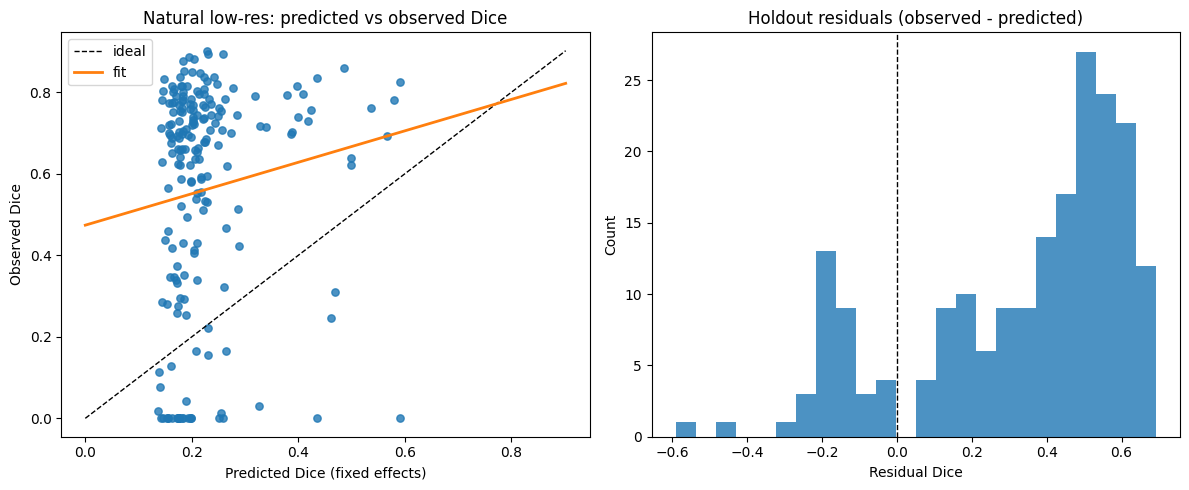

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs observed calibration scatter
ax = axes[0]
ax.scatter(pred, obs, alpha=0.8, s=28)
lo = min(float(np.min(pred)), float(np.min(obs)))
hi = max(float(np.max(pred)), float(np.max(obs)))
line = np.linspace(lo, hi, 200)
ax.plot(line, line, "k--", lw=1, label="ideal")

if len(pred) > 1:
    fit = np.polyfit(pred, obs, deg=1)
    ax.plot(line, fit[0] * line + fit[1], color="tab:orange", lw=2, label="fit")

ax.set_title("Natural low-res: predicted vs observed Dice")
ax.set_xlabel("Predicted Dice (fixed effects)")
ax.set_ylabel("Observed Dice")
ax.legend()

# Residual distribution
ax = axes[1]
ax.hist(holdout_df["residual"], bins=24, alpha=0.8)
ax.axvline(0.0, color="k", linestyle="--", lw=1)
ax.set_title("Holdout residuals (observed - predicted)")
ax.set_xlabel("Residual Dice")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


In [13]:
# Optional non-linear sensitivity model (GAM-like with cubic B-splines + clustered SEs)
if not active_predictors:
    print("No varying quality predictors available; skipping spline model.")
else:
    spline_terms = [f"bs({col}, df=4, degree=3, include_intercept=False)" for col in active_predictors]
    spline_formula = "1 + " + " + ".join(spline_terms)

    X_train = dmatrix(spline_formula, train_df, return_type="dataframe")
    if train_df["misalign"].nunique() > 1:
        X_train["misalign"] = train_df["misalign"].values

    spline_result = sm.OLS(train_df["logit_dice"], X_train).fit(
        cov_type="cluster",
        cov_kwds={"groups": train_df[GROUP_COL]},
    )

    print(spline_result.summary().tables[0])

    # Holdout prediction for comparison.
    # Clip to training bounds to avoid spline basis extrapolation errors.
    holdout_for_spline = holdout_df.copy()
    for col in active_predictors:
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        holdout_for_spline[col] = holdout_for_spline[col].clip(lo, hi)

    X_holdout = dmatrix(X_train.design_info, holdout_for_spline, return_type="dataframe")
    for col in X_train.columns:
        if col not in X_holdout.columns:
            X_holdout[col] = 0.0
    X_holdout = X_holdout[X_train.columns]

    holdout_df["pred_logit_spline"] = spline_result.predict(X_holdout)
    holdout_df["pred_soft_dice_spline"] = expit(holdout_df["pred_logit_spline"])

    obs = holdout_df[OUTCOME].to_numpy(dtype=float)
    pred_spline = holdout_df["pred_soft_dice_spline"].to_numpy(dtype=float)
    res_spline = obs - pred_spline

    spline_metrics = pd.Series(
        {
            "mae_spline": float(np.mean(np.abs(res_spline))),
            "rmse_spline": float(np.sqrt(np.mean(res_spline ** 2))),
            "bias_spline": float(np.mean(res_spline)),
            "pearson_r_spline": float(np.corrcoef(obs, pred_spline)[0, 1]),
        }
    )
    print(spline_metrics.to_string())


                            OLS Regression Results                            
Dep. Variable:             logit_dice   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     6.166
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           2.85e-07
Time:                        16:30:31   Log-Likelihood:                -2109.5
No. Observations:                 828   AIC:                             4239.
Df Residuals:                     818   BIC:                             4286.
Df Model:                           9                                         
Covariance Type:              cluster                                         
mae_spline          0.444612
rmse_spline         0.498955
bias_spline         0.391241
pearson_r_spline    0.016130


## Interpretation Checklist

- Check whether quality predictors actually vary by degradation (see the within-key spread table).
- If predictors do not vary across cohorts, the model can only learn subject-level associations, not degradation penalties.
- Use the holdout calibration bias (`observed - predicted`) to quantify any additional natural low-res penalty.
- If needed, recompute quality metrics directly on degraded images before final manuscript-level inference.
